# **Regresión y regularización con scikit-learn**

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

np.random.seed(42)

## Actividad 1
El archivo `data_1.txt` contiene un conjunto sencillo para regresión lineal. La primera columna corresponde a la variable independiente y la segunda a la variable objetivo.

Los datos representan el precio de una vivienda en función de la población de una ciudad. La población está expresada en unidades de 10.000 habitantes y el precio en unidades de 10.000 dólares.

1. Cargue los datos y represéntelos mediante un diagrama de dispersión.
2. Ajuste un modelo `LinearRegression`.
3. Obtenga y muestre el término independiente y la pendiente.
4. Obtenga y muestre los parámetros del modelo.
5. Grafique la recta ajustada sobre los datos.
6. Interprete el signo y la magnitud de la pendiente.


**1.** Se carga el archivo data_1.txt y con "head" vemos las primeras filas 

In [2]:
df_data1 = pd.read_csv("./data_1.txt", header=None, sep = ",")
df_data1.head()

,0,1
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


<Axes: title={'center': 'Diagrama de dispersión de data_1.txt'}, xlabel='0', ylabel='1'>

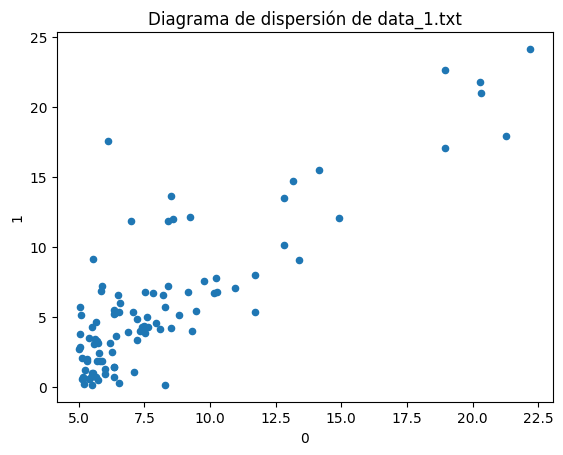

In [3]:
df_data1.plot(kind="scatter", x = 0, y = 1, title = "Diagrama de dispersión de data_1.txt")

Se representó al archivo mediante un diagrama de dispersión, donde el **eje x** representa a la **población** en unidades de 10.000 habitantes (es por eso que se ven valores como 5, 10, 15, 22.5 significa que esas ciudades tienen entre 50.000 y 225.000 habitantes aprox). El **eje y** representa a el **precio de una vivienda** en unidadas de 10.000 dólares, los puntos llegan hasta 24 aprox. representando viviendas de 240.000 dólares.

**2, 3 y 4.** Se ajusta al modelo con `LinearRegression`. Del mismo modo, se obtienen las variables dependientes (-3.58) e independientes (1.17) y se muestran los parámetros del modelo (1.17 y -3.58)

In [4]:
x = df_data1[[0]]
y = df_data1[1]
modelo_lin = LinearRegression()
modelo_lin.fit(x, y)
y_pred = modelo_lin.predict(x)
print ('Variable independiente: ', modelo_lin.coef_[0])
print ('Variable dependiente: ', modelo_lin.intercept_)
print ('Parametros del modelo: ', modelo_lin.coef_[0], modelo_lin.intercept_)

Variable independiente:  1.1697762389135078
Variable dependiente:  -3.5809620099565436
Parametros del modelo:  1.1697762389135078 -3.5809620099565436


**5.** Se grafica la recta ajustada sobre los datos

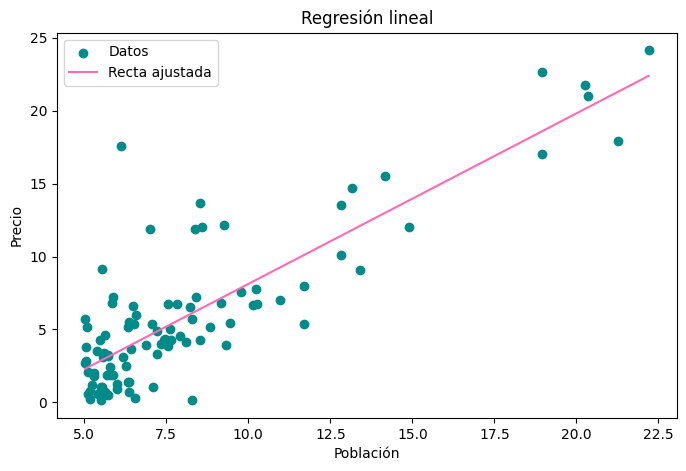

In [5]:
orden = np.argsort(x[0].to_numpy())

plt.figure(figsize=(8, 5))
plt.scatter(x[0], y, label="Datos", color="darkcyan")
plt.plot(
    x[0].to_numpy()[orden],
    y_pred[orden],
    color="hotpink",
    label="Recta ajustada"
)

plt.xlabel("Población")
plt.ylabel("Precio")
plt.title("Regresión lineal")
plt.legend()
plt.show()

## Actividad 2

Para analizar desempeño sobre datos no utilizados durante el ajuste, dividiremos `data_2.csv` en un conjunto de entrenamiento y otro de prueba.

1. Separe los datos en entrenamiento y prueba.
2. Ajuste `LinearRegression` usando únicamente el conjunto de entrenamiento.
3. Calcule MSE, RMSE y $R^2$ en ambos conjuntos.
4. Compare los errores y discuta si existe evidencia de un problema de generalización.

In [6]:
df_data2 = pd.read_csv("./data_2.csv", header=None, sep=",", skiprows=1)
df_data2.head()

,0,1
0,9.243561,20.798373
1,5.352573,14.425295
2,9.825191,27.804927
3,2.191246,10.313729
4,6.060049,17.087840


In [7]:
#separar el dataset en conjunto de entrenamiento y conjunto de prueba
train_set, test_set = train_test_split(df_data2, test_size = 0.2, random_state = 42)

#separamos feautures y targets en cada conjunto
train_labels = train_set.pop(1)
test_labels = test_set.pop(1)

In [8]:
#ajustamos el modelo lineal con el conjunto de entrenamiento
modelo_lin = LinearRegression()
modelo_lin.fit(train_set, train_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.37]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.701
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1826.03]


In [9]:
#Predecimos sobre ambos conjuntos de datos
train_predictions = modelo_lin.predict(train_set)
test_predictions = modelo_lin.predict(test_set)

#no se si aca deberiamos imprimir algo o no

In [10]:
#Calculamos metricas para train
mse_train = mean_squared_error(train_labels, train_predictions)
rmse_train = root_mean_squared_error(train_labels, train_predictions)
r2_train = r2_score(train_labels, train_predictions)

#Calculamos metricas para test
mse_test = mean_squared_error(test_labels, test_predictions)
rmse_test = root_mean_squared_error(test_labels, test_predictions)
r2_test = r2_score(test_labels, test_predictions)

In [11]:
#Comparamos resultados de train y test
print("Resultados para el conjunto de entrenamiento:")
print(f"MSE: {mse_train:.4f}")
print(f"RMSE: {rmse_train:.4f}")
print(f"R^2: {r2_train:.4f}")

print("\nResultados para el conjunto de prueba:")
print(f"MSE: {mse_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R^2: {r2_test:.4f}")

Resultados para el conjunto de entrenamiento:
MSE: 4.3114
RMSE: 2.0764
R^2: 0.9154

Resultados para el conjunto de prueba:
MSE: 4.3080
RMSE: 2.0756
R^2: 0.9151


A partir de estos resultados, podemos obervar que en todas las métricas, tanto en MSE, RMSE como $R^2$, los valores obtenidos en train y test son prácticamente iguales. Esto nos permite concluir que **el modelo generaliza bien** y que **no hay evidencia de overfitting**, ya que si hubiera un sobreajuste, esperariamos ver un $R^2$ notablemente más alto en train que en test, o un error mucho mayor en test que en train, y no es lo que obervamos.

## Actividad 3

1. Represente los datos.
2. Ajuste modelos polinomiales de grados 1, 3, 7 y 13.
3. Grafique las curvas sobre el mismo conjunto de datos.
4. Compare cómo cambia la forma de la función al aumentar el grado.
5. ¿Puede decidir cuál generaliza mejor mirando únicamente este gráfico? Justifique.

<Axes: title={'center': 'Representación de los datos'}, xlabel='0', ylabel='1'>

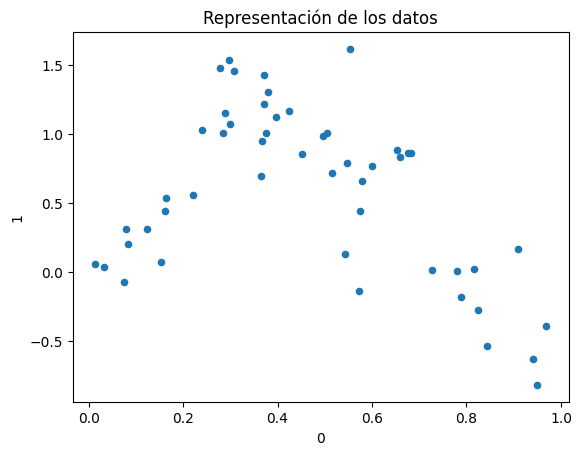

In [12]:
df_data3 = pd.read_csv("./data_3.csv", header=None, sep=",", skiprows=1)

df_data3.plot(kind="scatter", x = 0, y = 1, title = "Representación de los datos")

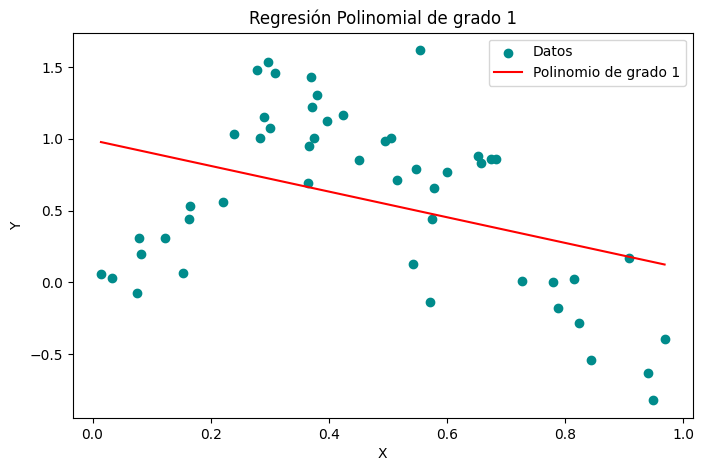

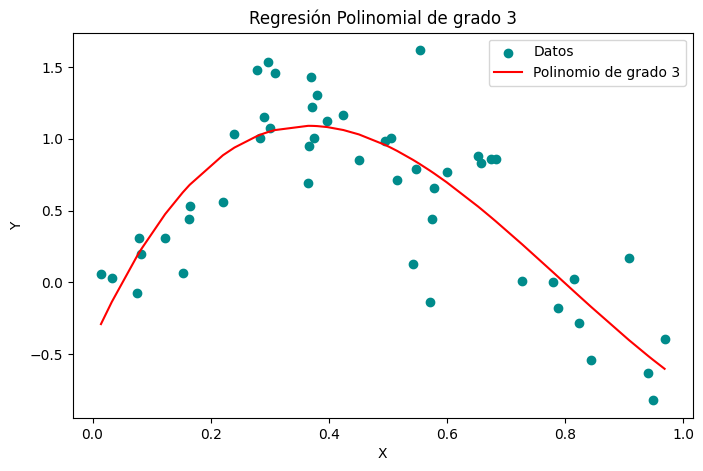

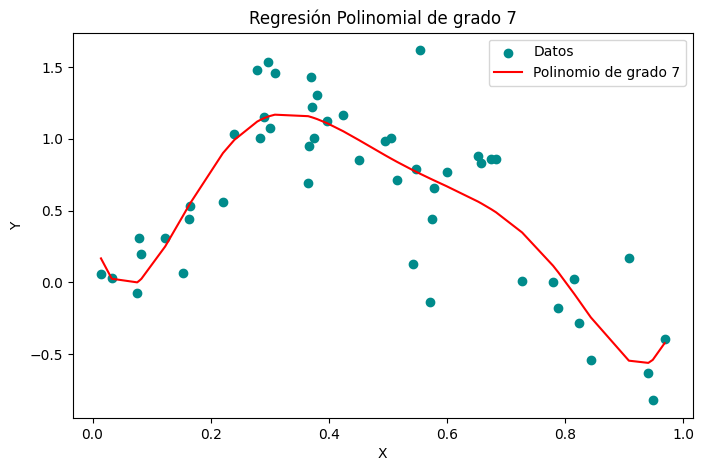

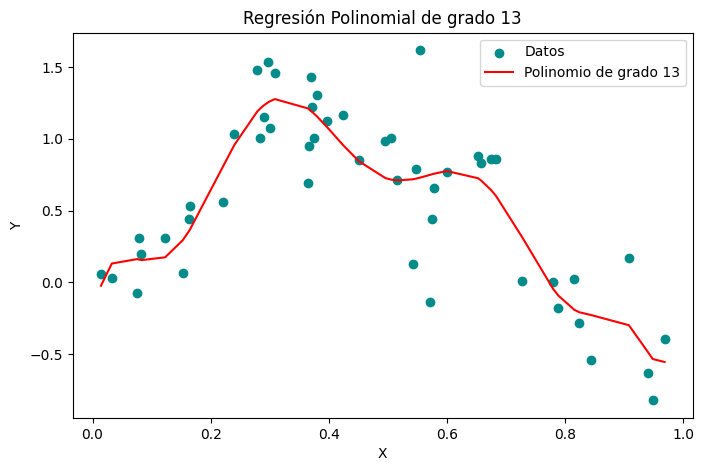

In [24]:
#Ajustamos un modelo de regresión polinomial para distintos grados y graficamos los resultados
for grado in [1, 3, 7, 13]:
    poly = PolynomialFeatures(degree=grado)
    X_poly = poly.fit_transform(df_data3[[0]])   
    std_scaler = StandardScaler()
    X_poly = std_scaler.fit_transform(X_poly)
    
    modelo = LinearRegression()
    modelo.fit(X_poly, df_data3[1])
    y_pred = modelo.predict(X_poly)

    plt.figure(figsize=(8, 5))
    plt.scatter(df_data3[0], df_data3[1], label="Datos", color="darkcyan")
    plt.plot(df_data3[0], y_pred, label=f"Polinomio de grado {grado}", color="red")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Regresión Polinomial de grado {grado}")
    plt.legend()
    plt.show()


Como se observa en las gráficas, a medida que aumenta el grado del polinomio, el **ajuste** a los datos de entrenamiento se vuelve cada vez más preciso, llegando incluso a ser **casi perfecto en los grados más altos** (como el 13). Sin embargo, eso es un claro indicio de sobreajuste (overfitting) ya que el polinomio comienza a modelar el ruido propio de los datos en lugar de la tendencia real subyacente.

Por este motivo, resulta conveniente **seleccionar un grado de polinomio** que logre **capturar la tendencia real** de los datos sin ajustarse al ruido, buscando un equilibrio adecuado entre sesgo y varianza. Un modelo con demasiado sesgo (grado muy bajo) puede no captar relaciones existentes en los datos, mientras que uno con demasiada varianza (grado muy alto) generaliza mal ante datos nuevos. Considerando esto, creemos conveniente que el **grado 3 constituye la mejor opción** para el modelo polinomial, ya que mantiene un buen ajuste sin incurrir en sobreajuste.

## Actividad 4

Ajuste modelos polinomiales sin regularización para diferentes grados (1, 3, 5, 7, 9, 11, 13, 15). Para cada grado:

1. calcule MSE y $R^2$ sobre entrenamiento;
2. calcule MSE y $R^2$ sobre validación;
3. grafique MSE de entrenamiento y validación en función del grado;
4. identifique evidencia de subajuste, buen compromiso y sobreajuste.

Si dos modelos presentan desempeños de validación muy similares, ¿qué otros criterios podrían utilizarse para preferir uno sobre otro?

In [14]:
#cargamos el archivo .mat
data7= scipy.io.loadmat("./data_7.mat")

x=data7['X']
y=data7['y'].ravel() #ravel() convierte la matriz de 2D a 1D, ya que y es un vector columna en el archivo .mat
xval=data7['Xval']
yval=data7['yval'].ravel()

In [15]:
grados= [1, 3, 5, 7, 9, 11, 13, 15]
mse_train_list = []
mse_val_list = []

for grado in grados:
    #creamos el transformador polinomial con el grado actual
    poly = PolynomialFeatures(degree=grado)

    #usamos fit_transform en train y transform en validacion para evitar data leakage
    X_poly_train = poly.fit_transform(x)
    X_poly_val = poly.transform(xval)

    #creamos y entrenamos un modelo de regresion lineal nuevo en cada vuelta
    modelo = LinearRegression()
    modelo.fit(X_poly_train, y)

    #generamos predicciones para train y validacion
    prediccion_train = modelo.predict(X_poly_train)
    prediccion_val = modelo.predict(X_poly_val)

    #calculamos el MSE para train y validacion
    mse_train = mean_squared_error(y, prediccion_train)
    mse_val = mean_squared_error(yval, prediccion_val)

    mse_train_list.append(mse_train)
    mse_val_list.append(mse_val)

    print(f"Grado: {grado}, MSE Train: {mse_train:.4f}, MSE Validation: {mse_val:.4f}")

Grado: 1, MSE Train: 62.0071, MSE Validation: 25.8297
Grado: 3, MSE Train: 14.2834, MSE Validation: 9.1812
Grado: 5, MSE Train: 15.1495, MSE Validation: 7.7396
Grado: 7, MSE Train: 15.1130, MSE Validation: 17.1461
Grado: 9, MSE Train: 17.7851, MSE Validation: 67.4906
Grado: 11, MSE Train: 39.8801, MSE Validation: 314.0251
Grado: 13, MSE Train: 49.1654, MSE Validation: 643.1206
Grado: 15, MSE Train: 57.6994, MSE Validation: 1155.4163


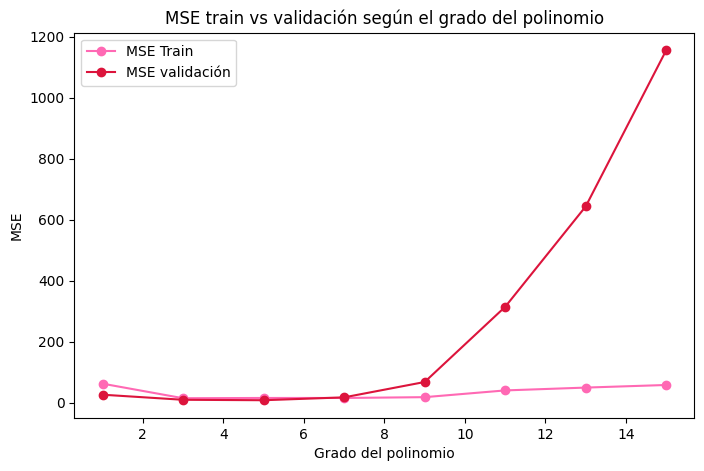

In [16]:
#Graficamos los resultados
plt.figure(figsize=(8, 5))
plt.plot(grados, mse_train_list, marker='o', label='MSE Train', color='hotpink')
plt.plot(grados, mse_val_list, marker='o', label='MSE validación', color='crimson')
plt.xlabel('Grado del polinomio')
plt.ylabel('MSE')
plt.title('MSE train vs validación según el grado del polinomio')
plt.legend()
plt.show()

In [17]:
mejor_indice = np.argmin(mse_val_list)
mejor_grado = grados[mejor_indice]
print(f"El grado con el MSE de validación más bajo es: {mejor_grado}")
print(f"MSE de validación en ese grado: {mse_val_list[mejor_indice]:.4f}")

El grado con el MSE de validación más bajo es: 5
MSE de validación en ese grado: 7.7396


A partir de los resultados obtenidos, es posible observar que el MSE alcanza su valor mínimo en el grado 5 (MSE = 7.74). Esto indica que este es el grado polinomial que logra el nivel de flexibilidad adecuado para representar la estructura de los datos, alcanzando un mejor ajuste entre el sesgo y la varianza para este conjunto de datos. 

Para grados menores a 5, el modelo presenta un comportamiento de **subajuste**, ya que al ser demasiado simple no logra capturar la estructura subyacente de los datos, lo que se traduce como un error de entrenamiento relativamente alto que también se refleja en el conjunto de validación. En este rango el **modelo tiene mayor sesgo**.

A partir del grado 9 en adelante, se observa **sobreajuste**, el MSE de entrenamiento se mantiene bajo y estable, mientras que el MSE de validación crece de forma cada vez más pronunciada. Esto ocurre porque el aumento de la flexibilidad del modelo le permite ajustarse no solo a la tendencia real de los datos, sino también al ruido particular del conjunto de entrenamiento, haciendo que el modelo se vuelva más sensible a variaciones especificas de esos datos, lo que se traduce como una **mayor varianza**.

Entonces, a medida que aumenta el grado del polinomio, aumenta la flexibilidad del modelo. El sesgo disminuye pero la varianza aumenta, lo cual ilustra claramente el compromiso sesgo-varianza.

## Actividad 5

Compare, para los mismos grados polinomiales:

- regresión sin regularización;
- Ridge;
- Lasso;
- Elastic Net.

Compare el MSE de validación de los cuatro modelos y determine qué combinación de complejidad y regularización ofrece mejor desempeño sobre los datos de validación.

In [18]:
modelos_regularizacion = {
    "Sin regularización": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

In [19]:
resultados_regularizacion = {nombre: [] for nombre in modelos_regularizacion}

for grado in grados:
    for nombre, modelo in modelos_regularizacion.items():
        #pipeline transforma el polinomio, lo escala y despues aplica el modelo
        pipeline = Pipeline([
            ('poly', PolynomialFeatures(degree=grado)),
            ('scaler', StandardScaler()),
            ('model', modelo)
        ])

        #el pipelina entero se ajusta a los datos de entrenamiento
        pipeline.fit(x, y)

        #predecimos sobre valdidacion 
        predicciones_val = pipeline.predict(xval)
        mse_val = mean_squared_error(yval, predicciones_val)

        resultados_regularizacion[nombre].append(mse_val)

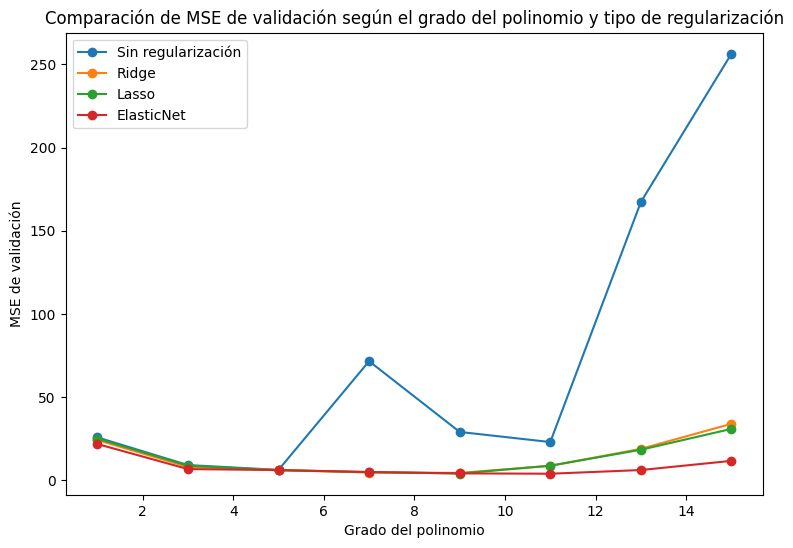

In [20]:
#graficamos las 4 curvas de MSE de validacion juntas
plt.figure(figsize=(9, 6))
for nombre, mse_list in resultados_regularizacion.items():
    plt.plot(grados, mse_list, marker='o', label=nombre)

plt.xlabel('Grado del polinomio')
plt.ylabel('MSE de validación')
plt.title('Comparación de MSE de validación según el grado del polinomio y tipo de regularización')
plt.legend()
plt.show()

A partir de estos resultados, se observa que el modelo sin regularización presenta un pico muy pronunciado de error en los grados altos del polinomio (llegando a valores de 250 en el grado 15), mientras que Ridge, Lazzo y ElasticNet se mantienen en valores bajos y estables a lo largo de todo el rango de valores evaluados. Esto demuestra que **la regularización frena el overfitting** que aparece con polinomios de grados más altos, ya que al penalizar la magnitud de los coeficientes, evita que el modelo se vuelva excesivamente flexible y termine ajustandose demas al ruido del conjunto de entrenamiento, que es lo que ocurre en el modelo sin regularizar. 

Entre las tres técnicas de regularización, el comportamiento es bastante similar, aunque **ElasticNet** se mantiene un poco más baja que Ridge y Lazzo en los grados más altos

## Actividad 6

Seleccione el grado polinomial 15 y grafique las curvas ajustadas por los cuatro modelos. Relacione:

- forma de la curva;
- flexibilidad aparente del modelo;
- MSE de entrenamiento;
- MSE de validación.

Explique por qué una curva visualmente más ajustada a entrenamiento puede tener peor desempeño de validación.

In [21]:
grado_fijo=15

In [22]:
#pipeline para los 4 modelos de regularización
pipelines_grado15 = {
    "Sin regularización": Pipeline([
        ('poly', PolynomialFeatures(degree=grado_fijo)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    "Ridge": Pipeline([
        ('poly', PolynomialFeatures(degree=grado_fijo)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ('poly', PolynomialFeatures(degree=grado_fijo)),
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.1))
    ]),
    "ElasticNet": Pipeline([
        ('poly', PolynomialFeatures(degree=grado_fijo)),
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.1, l1_ratio=0.5))
    ]), 
}

Sin regularización - MSE Train: 1.5737, MSE Validation: 256.3906
Ridge - MSE Train: 11.3116, MSE Validation: 33.9818
Lasso - MSE Train: 11.1145, MSE Validation: 30.9293
ElasticNet - MSE Train: 12.5376, MSE Validation: 11.7179


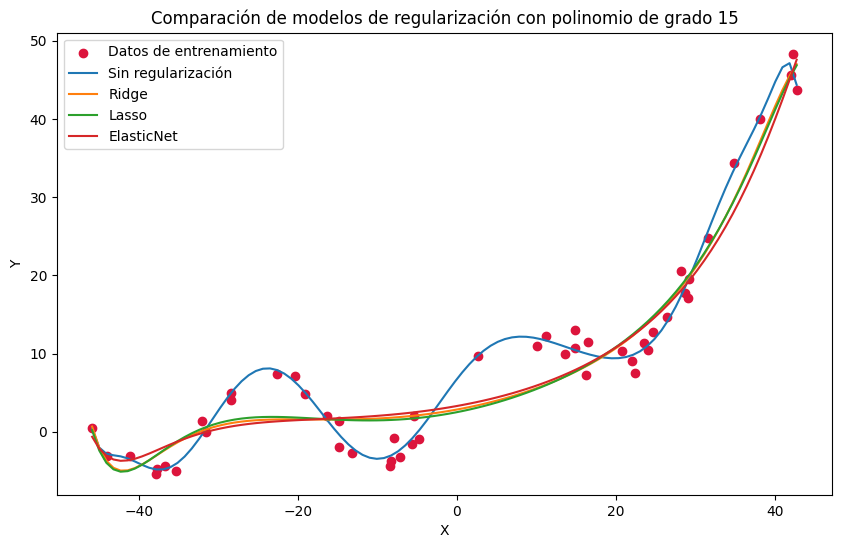

In [23]:
#rango de valores de x ordenados para graficar curvas suave
x_rango = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="Datos de entrenamiento", color="crimson")

resultadosg15= {}
for nombre, pipeline in pipelines_grado15.items():
    #ajustamos el pipeline a los datos de entrenamiento
    pipeline.fit(x, y)

    #predecimos sobre el rango de x para graficar la curva
    y_rango_pred = pipeline.predict(x_rango)

    #graficamos la curva ajustada
    plt.plot(x_rango, y_rango_pred, label=nombre)

    #MSE de train y validacion para relacionar con la forma de la curva
    mse_train = mean_squared_error(y, pipeline.predict(x))
    mse_val = mean_squared_error(yval, pipeline.predict(xval))
    resultadosg15[nombre] = (mse_train, mse_val)
    print(f"{nombre} - MSE Train: {mse_train:.4f}, MSE Validation: {mse_val:.4f}")

plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Comparación de modelos de regularización con polinomio de grado {grado_fijo}")
plt.legend()    
plt.show()

Al fijar el grado del polinomio en 15 y graficar las curvas ajustadas por los cuatro modelos, se observa una diferencia clara en la forma de cada una. La curva del modelo sin regularización es visiblemente más ondulada, en cambio, las curvas de Ridge, Lazzo y ElasticNet son mucho más suaves y se mantienen casi superpuestas entre sí.

Esta diferencia visual se corresponde con los valores de MSE encontrados. El modelo sin regularización presenta el menor error de entrenamiento de los cuatro (MSE = 1.57), pero al mismo tiempo el error de validación más alto (MSE = 256.39), esta combinación es la **evidencia numérica del overfitting** que se observa en al curva.

Los modelos regularizados, en cambio, muestran un MSE de entrenamiento más alto (entre 11 y 12.5) pero sus valores de MSE de validación son notablemente menores, siendo ElasticNet el que logra el mejor resultado (MSE = 11.72).

Esto confirma que un **modelo que ajusta mejor los datos de entrenamiento no necesariamente es el que mejor se va a desempeñar ante datos nuevos**

## Actividad 7

Mantenga fijo un grado polinomial alto (15) y evalúe distintos valores de `alpha` para Ridge. Compare MSE de entrenamiento y validación en función de `alpha`.

A partir de las curvas obtenidas, identifique qué valores de alpha producen subajuste y cuál ofrece el mejor compromiso entre error de entrenamiento y validación. Justifique a partir de los resultados.

In [26]:
grado_fijo=15
alphas = [1e-6, 1e-3, 0.01, 0.1, 1, 10, 100]
resultados = []
for alpha in alphas:
    pipeline = Pipeline([
            ('poly', PolynomialFeatures(degree=grado_fijo)),
            ('scaler', StandardScaler()),
            ('model', Ridge(alpha=alpha))
        ])

    pipeline.fit(x, y)

    y_train_pred = pipeline.predict(x)
    y_val_pred = pipeline.predict(xval)

    mse_train = mean_squared_error(y, y_train_pred)
    mse_val = mean_squared_error(yval, y_val_pred)
    resultados.append({'alpha': alpha, 'mse_train': mse_train, 'mse_val': mse_val})

df_result = pd.DataFrame(resultados)
df_result

,alpha,mse_train,mse_val
0,0.000001,1.652664,231.390656
1,0.001000,3.309298,64.624532
2,0.010000,5.371060,11.011271
3,0.100000,8.776583,56.790132
4,1.000000,11.311608,33.981843
5,10.000000,14.898452,5.998714
6,100.000000,39.560944,15.776024


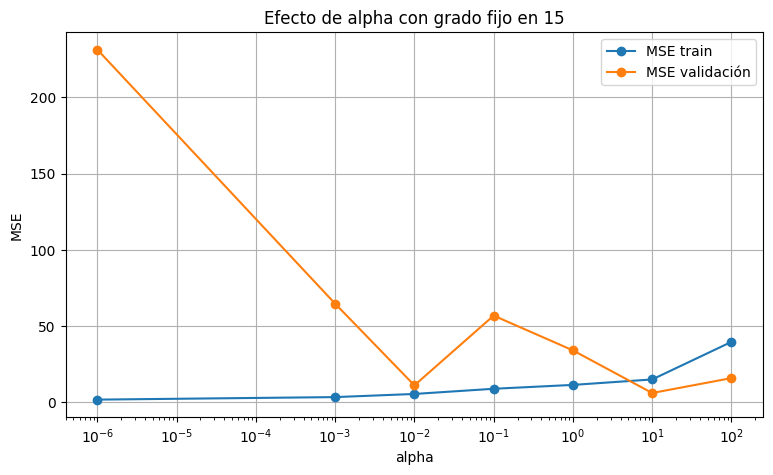

In [27]:
#Hacemos un grafico para comparar 
plt.figure(figsize=(9, 5))
plt.plot(df_result["alpha"], df_result["mse_train"], marker="o", label="MSE train")
plt.plot(df_result["alpha"], df_result["mse_val"], marker="o", label="MSE validación")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("MSE")
plt.title("Efecto de alpha con grado fijo en 15")
plt.legend()
plt.grid(True)
plt.show()

Como se observa en la gráfica, manteniendo el grado polinomial fijo en 15, el valor de alpha determina fuertemente el comportamiento del modelo. Para los **valores más chicos de alpha** (1e-6 y 1e-3), la regularización es prácticamente nula, por lo que el modelo conserva toda la flexibilidad que le da un polinomio de grado 15 y termina ajustando el ruido propio del conjunto de entrenamiento. Esto se refleja en un MSE de entrenamiento muy bajo (1.65 y 3.31 respectivamente) frente a un MSE de validación mucho más alto (231.39 y 64.62).

Luego si observamos con **alpha = 100** la penalización sobre los coeficientes es tan fuerte que el modelo pierde capacidad de representar la relación real entre las variables: los coeficientes se ven forzados hacia valores muy pequeños y el modelo se vuelve demasiado simple. Esto se evidencia en que el MSE de entrenamiento aumenta notoriamente (39.56), incluso más que el de validación (15.78), lo cual es la firma característica del subajuste.

El **alpha = 10** es el que ofrece el **mejor compromiso entre ambos errores**, debido a que presenta el MSE de validación más bajo de toda la grilla evaluada (5.998714), junto con un MSE de entrenamiento moderado (14.90), sin la brecha excesiva del sobreajuste ni el deterioro conjunto propio del subajuste. Esto indica que, para este grado polinomial fijo, alpha = 10 logra el nivel de regularización adecuado